In [1]:
pip install pandas plotly kaleido openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import plotly.graph_objects as go

df_2021 = pd.read_csv(
    r"C:\Users\anshu\Downloads\input_files_for_participants_rpc\input_files_for_participants_rpc\data\tn_2021_results.csv"
)

df_2026 = pd.read_csv(
    r"C:\Users\anshu\Downloads\input_files_for_participants_rpc\input_files_for_participants_rpc\data\tn_2026_results.csv"
)

df_master = pd.read_csv(
    r"C:\Users\anshu\Downloads\input_files_for_participants_rpc\input_files_for_participants_rpc\data\constituency_master.csv"
)

print(df_2021.shape)
print(df_2026.shape)
print(df_master.shape)

(4232, 8)
(4257, 8)
(234, 5)


Build Winners Tables

In [3]:
w2021 = (
    df_2021
    .sort_values(["ac_number", "votes"], ascending=[True, False])
    .groupby("ac_number")
    .first()
    .reset_index()
    [["ac_number", "constituency", "party", "votes", "region", "reserved"]]
    .rename(columns={"party": "party_2021", "votes": "votes_2021"})
)

w2026 = (
    df_2026
    .sort_values(["ac_number", "votes"], ascending=[True, False])
    .groupby("ac_number")
    .first()
    .reset_index()
    [["ac_number", "party", "votes"]]
    .rename(columns={"party": "party_2026", "votes": "votes_2026"})
)

print("Winners 2021:", len(w2021), "| Winners 2026:", len(w2026))

Winners 2021: 234 | Winners 2026: 234


Total Valid Votes Per Constituency

In [4]:
tv2021 = (
    df_2021
    .groupby("ac_number")["votes"]
    .sum()
    .reset_index()
    .rename(columns={"votes": "total_votes_2021"})
)

tv2026 = (
    df_2026
    .groupby("ac_number")["votes"]
    .sum()
    .reset_index()
    .rename(columns={"votes": "total_votes_2026"})
)

Build constituency_results (Main Table)

In [5]:
results = (
    w2021
    .merge(w2026, on="ac_number")
    .merge(df_master[["ac_number", "district"]], on="ac_number")
    .merge(tv2021, on="ac_number")
    .merge(tv2026, on="ac_number")
)

results["win_pct_2021"] = (results["votes_2021"] / results["total_votes_2021"] * 100).round(2)
results["win_pct_2026"] = (results["votes_2026"] / results["total_votes_2026"] * 100).round(2)
results["flipped"] = results["party_2021"] != results["party_2026"]
results["flip_direction"] = results.apply(
    lambda r: f"{r['party_2021']} → {r['party_2026']}" if r["flipped"] else "Held",
    axis=1
)
results["win_pct_change"] = (results["win_pct_2026"] - results["win_pct_2021"]).round(2)

print(results.shape)
print(results.head(3))

(234, 16)
   ac_number  constituency party_2021  votes_2021         region reserved  \
0          1  Gummidipundi        DMK      126452  Chennai Metro      GEN   
1          2       Ponneri        INC       94528  Chennai Metro       SC   
2          3     Tiruttani        DMK      120314  Chennai Metro      GEN   

  party_2026  votes_2026    district  total_votes_2021  total_votes_2026  \
0        TVK       94320  Tiruvallur            222069            232522   
1        TVK      110439  Tiruvallur            210354            226819   
2     AIADMK       89169  Tiruvallur            232624            238798   

   win_pct_2021  win_pct_2026  flipped flip_direction  win_pct_change  
0         56.94         40.56     True      DMK → TVK          -16.38  
1         44.94         48.69     True      INC → TVK            3.75  
2         51.72         37.34     True   DMK → AIADMK          -14.38  


 Build party_voteshare (Long Format Table)

In [6]:
df_2021["year"] = 2021
df_2026["year"] = 2026

both = pd.concat([df_2021, df_2026], ignore_index=True)

tv_both = both.groupby(["ac_number", "year"])["votes"].sum().reset_index().rename(columns={"votes": "total_votes"})

voteshare = (
    both
    .merge(tv_both, on=["ac_number", "year"])
)

voteshare["vote_share_pct"] = (voteshare["votes"] / voteshare["total_votes"] * 100).round(2)

print(voteshare.shape)
print(voteshare.head(3))

(8489, 11)
   constituency  ac_number         candidate party   votes  turnout reserved  \
0  Gummidipundi          1  GOVINDARAJAN T.J   DMK  126452    78.08      GEN   
1  Gummidipundi          1         PRAKASH M   PMK   75514    78.08      GEN   
2  Gummidipundi          1              USHA   NTK   11701    78.08      GEN   

          region  year  total_votes  vote_share_pct  
0  Chennai Metro  2021       222069           56.94  
1  Chennai Metro  2021       222069           34.00  
2  Chennai Metro  2021       222069            5.27  


Build sankey_df + export all files   

In [7]:
# Add margin of victory in votes
def get_second_place_votes(ac_num, df):
    sub = df[df['ac_number'] == ac_num].sort_values('votes', ascending=False)
    if len(sub) > 1:
        return sub['votes'].iloc[1]
    return 0

results['second_votes_2026'] = results['ac_number'].apply(
    lambda x: get_second_place_votes(x, df_2026)
)
results['margin_votes_2026'] = results['votes_2026'] - results['second_votes_2026']

# Re-export with new column
output_path = r"C:\Users\anshu\Downloads\tn-election-2026\data\processed"
results.to_csv(rf"{output_path}\constituency_results.csv", index=False)

print("Re-exported with margin_votes_2026")
print(results[['constituency','party_2026','margin_votes_2026','win_pct_2026']].sort_values('margin_votes_2026').head(5).to_string(index=False))

Re-exported with margin_votes_2026
 constituency party_2026  margin_votes_2026  win_pct_2026
  Tiruppattur        TVK                  1         38.65
 Veppanahalli        DMK                138         33.55
Kanniyakumari     AIADMK                214         31.38
        Polur        TVK                227         32.10
 Tirukkoyilur     AIADMK                285         33.61


Build Sankey Source Data

In [8]:
# Major parties list
major_parties = ["DMK", "AIADMK", "TVK", "INC", "PMK", "VCK", "BJP", "CPI", "CPI(M)"]

# Add grouped party columns
results["p21"] = results["party_2021"].apply(lambda x: x if x in major_parties else "Others")
results["p26"] = results["party_2026"].apply(lambda x: x if x in major_parties else "Others")

# Add margin of victory in votes
def get_second_place_votes(ac_num, df):
    sub = df[df['ac_number'] == ac_num].sort_values('votes', ascending=False)
    if len(sub) > 1:
        return sub['votes'].iloc[1]
    return 0

results['second_votes_2026'] = results['ac_number'].apply(
    lambda x: get_second_place_votes(x, df_2026)
)
results['margin_votes_2026'] = results['votes_2026'] - results['second_votes_2026']

# Build sankey flows
sankey_df = (
    results
    .groupby(["p21", "p26"])
    .size()
    .reset_index(name="seats")
    .sort_values("seats", ascending=False)
)

# Export AFTER all columns are added
results.to_csv(rf"{output_path}\constituency_results.csv", index=False)
voteshare.to_csv(rf"{output_path}\party_voteshare.csv", index=False)
sankey_df.to_csv(rf"{output_path}\sankey_flows.csv", index=False)

print("All files exported to:", output_path)
print("Columns in results:", list(results.columns))
print()
print(sankey_df.head(10))

All files exported to: C:\Users\anshu\Downloads\tn-election-2026\data\processed
Columns in results: ['ac_number', 'constituency', 'party_2021', 'votes_2021', 'region', 'reserved', 'party_2026', 'votes_2026', 'district', 'total_votes_2021', 'total_votes_2026', 'win_pct_2021', 'win_pct_2026', 'flipped', 'flip_direction', 'win_pct_change', 'second_votes_2026', 'margin_votes_2026', 'p21', 'p26']

       p21     p26  seats
16     DMK     TVK     65
13     DMK     DMK     40
4   AIADMK     TVK     26
0   AIADMK  AIADMK     22
11     DMK  AIADMK     22
1   AIADMK     DMK     15
21     INC     TVK     11
19     INC     INC      4
15     DMK     PMK      3
24     PMK     TVK      2


KPI Verification Printout

In [9]:
print("=" * 50)
print("KPI VERIFICATION")
print("=" * 50)

print(f"Total constituencies: {len(results)}")
print(f"Flipped: {results['flipped'].sum()} ({results['flipped'].mean()*100:.1f}%)")
print(f"Held: {(~results['flipped']).sum()}")
print()

print("Seat count 2021:")
print(results["party_2021"].value_counts().head(8))
print()
print("Seat count 2026:")
print(results["party_2026"].value_counts().head(8))
print()

sc = results[results["reserved"] == "SC"]
gen = results[results["reserved"] == "GEN"]
print(f"SC flip rate: {sc['flipped'].mean()*100:.1f}%")
print(f"GEN flip rate: {gen['flipped'].mean()*100:.1f}%")
print()

print(f"Avg win% 2021: {results['win_pct_2021'].mean():.2f}%")
print(f"Avg win% 2026: {results['win_pct_2026'].mean():.2f}%")
print(f"Seats won >50% in 2021: {(results['win_pct_2021'] > 50).sum()}")
print(f"Seats won >50% in 2026: {(results['win_pct_2026'] > 50).sum()}")
print(f"Seats won <35% in 2021: {(results['win_pct_2021'] < 35).sum()}")
print(f"Seats won <35% in 2026: {(results['win_pct_2026'] < 35).sum()}")

KPI VERIFICATION
Total constituencies: 234
Flipped: 163 (69.7%)
Held: 71

Seat count 2021:
party_2021
DMK       133
AIADMK     66
INC        18
PMK         5
VCK         4
BJP         4
CPI         2
CPI(M)      2
Name: count, dtype: int64

Seat count 2026:
party_2026
TVK       108
DMK        59
AIADMK     47
INC         5
PMK         4
IUML        2
CPI         2
VCK         2
Name: count, dtype: int64

SC flip rate: 70.5%
GEN flip rate: 69.7%

Avg win% 2021: 48.41%
Avg win% 2026: 38.83%
Seats won >50% in 2021: 70
Seats won >50% in 2026: 13
Seats won <35% in 2021: 2
Seats won <35% in 2026: 64


Sankey Diagram (Plotly)

In [10]:
output_path = r"C:\Users\anshu\Downloads\tn-election-2026\data\processed"

# Filter: only show actual flips (where p21 != p26), remove self-loops
sankey_flips = sankey_df[sankey_df["p21"] != sankey_df["p26"]].copy()

nodes = ["AIADMK", "BJP", "CPI", "CPI(M)", "DMK", "INC", "Others", "PMK", "TVK", "VCK"]
node_index = {name: i for i, name in enumerate(nodes)}

node_colors = [
    "#E8A838",  # AIADMK
    "#FF6B35",  # BJP
    "#CC0000",  # CPI
    "#AA0000",  # CPI(M)
    "#E63946",  # DMK
    "#457B9D",  # INC
    "#ADB5BD",  # Others
    "#2DC653",  # PMK
    "#8338EC",  # TVK
    "#06D6A0",  # VCK
]

source = [node_index[r] for r in sankey_flips["p21"]]
target = [node_index[r] for r in sankey_flips["p26"]]
value  = list(sankey_flips["seats"])

fig = go.Figure(go.Sankey(
    arrangement="freeform",
    node=dict(
        pad=30,
        thickness=30,
        line=dict(color="white", width=0.5),
        label=nodes,
        color=node_colors,
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(180,180,180,0.35)",
    )
))

fig.update_layout(
    title_text="163 Seats Changed Hands: Where Did They Go? (2021 → 2026)",
    title_font_size=17,
    font_size=13,
    width=1100,
    height=700,
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.write_html(rf"{output_path}\sankey_tn_2026.html")
fig.write_image(rf"{output_path}\sankey_tn_2026.png", scale=2)
fig.show()

Win % Distribution Chart

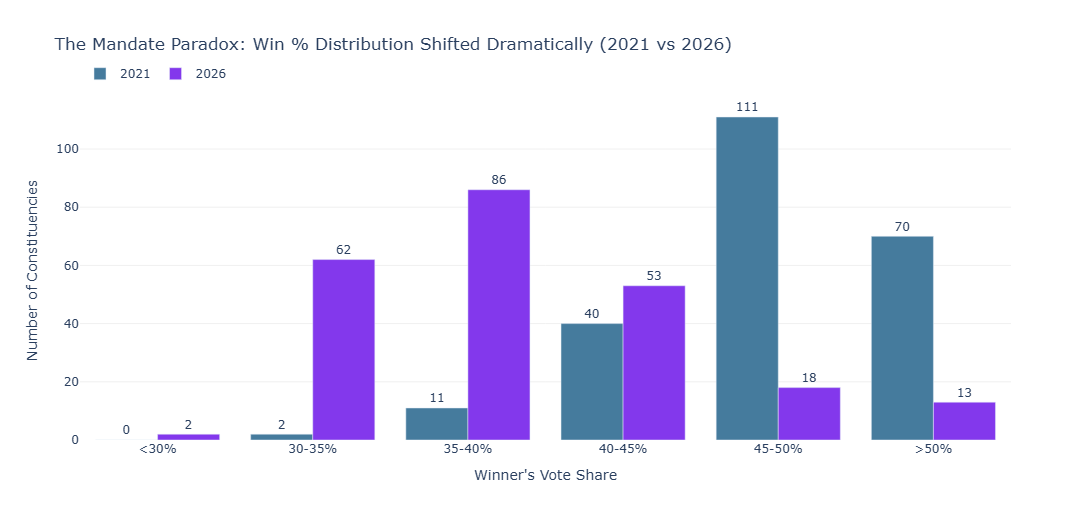

In [11]:
output_path = r"C:\Users\anshu\Downloads\tn-election-2026\data\processed"

bins_labels = ["<30%", "30-35%", "35-40%", "40-45%", "45-50%", ">50%"]

counts_2021 = [
    (results["win_pct_2021"] < 30).sum(),
    ((results["win_pct_2021"] >= 30) & (results["win_pct_2021"] < 35)).sum(),
    ((results["win_pct_2021"] >= 35) & (results["win_pct_2021"] < 40)).sum(),
    ((results["win_pct_2021"] >= 40) & (results["win_pct_2021"] < 45)).sum(),
    ((results["win_pct_2021"] >= 45) & (results["win_pct_2021"] < 50)).sum(),
    (results["win_pct_2021"] >= 50).sum(),
]

counts_2026 = [
    (results["win_pct_2026"] < 30).sum(),
    ((results["win_pct_2026"] >= 30) & (results["win_pct_2026"] < 35)).sum(),
    ((results["win_pct_2026"] >= 35) & (results["win_pct_2026"] < 40)).sum(),
    ((results["win_pct_2026"] >= 40) & (results["win_pct_2026"] < 45)).sum(),
    ((results["win_pct_2026"] >= 45) & (results["win_pct_2026"] < 50)).sum(),
    (results["win_pct_2026"] >= 50).sum(),
]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name="2021", x=bins_labels, y=counts_2021,
    marker_color="#457B9D",
    text=counts_2021, textposition="outside"
))
fig2.add_trace(go.Bar(
    name="2026", x=bins_labels, y=counts_2026,
    marker_color="#8338EC",
    text=counts_2026, textposition="outside"
))

fig2.update_layout(
    barmode="group",
    title="The Mandate Paradox: Win % Distribution Shifted Dramatically (2021 vs 2026)",
    xaxis_title="Winner's Vote Share",
    yaxis_title="Number of Constituencies",
    width=950,
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="white",
    legend=dict(orientation="h", y=1.12),
    yaxis=dict(gridcolor="#f0f0f0"),
)

fig2.write_image(rf"{output_path}\win_distribution.png", scale=2)
fig2.show()